# Eye-in-Hand Calibration

In this example, you will learn how to compute the transformation between camera pixel coordinates and robot arm coordinates, enabling the robot to move based on objects detected in the image. This is a fundamental step in applications such as object detection and robotic pick-and-place tasks.

In this example, the manipulator and camera of the MIRTE platform will not be used, as implementing the setup on MIRTE is something you can do yourself. Instead, the example is based on the KINOVA Gen3 robot. However, the same principles can be adapted to virtually any robotic platform.

**Note**: If the camera is stationary and not mounted on the hand, the process is simpler, but the same steps described here can still be used. This variant is called **Hand-to-Eye** calibration.


## Camera Parameters

A camera is typically described by two sets of parameters: **intrinsic parameters** and **extrinsic parameters**.

The intrinsic parameters describe the internal characteristics of the camera, such as the **focal length**, **optical center**, and **lens distortion**. These parameters define how 3D points are projected onto the 2D image plane.

The extrinsic parameters describe the position and orientation of the camera with respect to a reference coordinate frame in the real world. In other words, they represent the transformation between the camera coordinate frame and another frame, such as the robot base or the world frame. This transformation allows image observations to be related to real-world coordinates.


## Intrinsic Parameters

To find the intrinsic parameters of a camera, a calibration target (such as a checkerboard) is used to estimate these parameters. Since this has been covered in previous practicum, the intrinsic parameters for the camera used in this example are provided and can be loaded directly using the code below.


In [ ]:
# import necessary libraries
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import numpy as np

In [ ]:
with open("intrinsic_params.json", "r") as f:
    params = json.load(f)
params = params["intrinsics"]

Now you can inspect valuable properties such as the camera's focal length. The parameters are accessible as a dictionary.


In [ ]:
print(params.keys())

In [ ]:
assert set(params.keys()) == {
    'FocalLength',
    'PrincipalPoint',
    'ImageSize',
    'RadialDistortion',
    'TangentialDistortion',
    'Skew',
    'K'
}, f"Unexpected keys found: {params.keys()}"

## Collecting the Required Data

For hand-eye calibration, you must capture 15–30 images from different perspectives. You should ensure that the set of robot poses covers a wide range of the robot manipulator's workspace. Using these images together with the intrinsic parameters of the camera, you can determine the transformation between the calibration board and the camera. An example image is shown below.


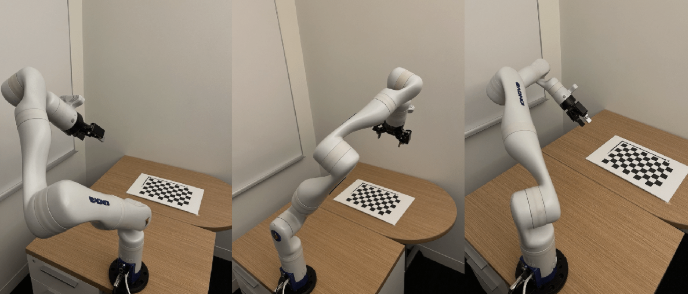

This can be done easily with MIRTE and a simple checkerboard. Note that the intrinsic parameters of the MIRTE hand camera are already provided. If you were to compute them yourself, the images used to estimate the intrinsic parameters and the images used for the eye-in-hand calibration should generally be different sets.


In [ ]:
# Loading images obtained from the camera on top of the KINOVA Gen3 robot arm.
# Folder containing calibration images
image_folder = Path("calibrationData")

# Load all PNG images into a list
images = [Image.open(img_path) for img_path in sorted(image_folder.glob("*.png"))]

# Check how many images were loaded
print(f"Loaded {len(images)} images.")

# Show the first image
plt.imshow(images[0])
plt.title("First Calibration Image")
plt.axis("off")
plt.show()

## Estimate Extrinsic Parameters

In this step, you estimate the camera's extrinsic parameters, which involve determining the transformation of the calibration board's origin with respect to the camera for each pose. The extrinsics estimation process locates the calibration checkerboard corners within the undistorted image. These points are then used to determine the camera's position and orientation relative to the calibration board.


First, let us prepare the two inputs that `solvePnP` requires in every iteration: the camera model (intrinsic matrix $K$ and distortion coefficients) and the real-world 3D coordinates of the board corners. These are the same for all images.


In [ ]:
square_size = 0.022  # meters

# Camera intrinsic matrix
K = np.array(params["K"], dtype=np.float64)

# Build OpenCV distortion vector [k1, k2, p1, p2, k3]
radial = np.array(params["RadialDistortion"]).flatten()
tangential = np.array(params["TangentialDistortion"]).flatten()

if len(radial) == 2:
    dist_coeffs = np.array([
        radial[0], radial[1],
        tangential[0], tangential[1],
        0.0  # k3 not provided, set to zero
    ], dtype=np.float64)
else:
    dist_coeffs = np.array([
        radial[0], radial[1],
        tangential[0], tangential[1],
        radial[2]  # k3
    ], dtype=np.float64)

checkerboard_size = (9, 6)  # inner corners (columns, rows)

# 3D world points of the checkerboard corners, z=0 since the board is flat
world_points = np.zeros(
    (checkerboard_size[0] * checkerboard_size[1], 3),
    dtype=np.float32
)

world_points[:, :2] = np.mgrid[
    0:checkerboard_size[0],
    0:checkerboard_size[1]
].T.reshape(-1, 2)

world_points *= square_size  # convert from grid indices to meters

Now, let us estimate the transformations between the camera frame and the checkerboard frame, as discussed in class. In OpenCV, this pose estimation problem is solved using the `solvePnP()` function, which computes the rotation and translation of the checkerboard with respect to the camera from the detected image points and the known 3D checkerboard coordinates.


The 3D checkerboard points are defined in the checkerboard frame:

$$
{}^{g}\mathbf{p}_i =
\begin{bmatrix}
X_i \\
Y_i \\
Z_i
\end{bmatrix}
$$

The detected image points are:

$$
\mathbf{u}_i =
\begin{bmatrix}
u_i \\
v_i
\end{bmatrix}
$$

`solvePnP()` estimates a rotation vector $\mathbf{r}$ and a translation vector $\mathbf{t}$, which together describe the transform from the checkerboard frame $g$ to the camera frame $c$.

In equation form:

$$
{}^{c}\mathbf{p}_i
=
{}^{c}R_{g} \, {}^{g}\mathbf{p}_i
+
{}^{c}\mathbf{t}_{g}
$$

where:

$$
{}^{c}R_{g} = \mathrm{Rodrigues}(\mathbf{r})
$$

**Rodrigues** converts an axis-angle rotation representation into a 3×3 rotation matrix.

The homogeneous transformation matrix is:

$$
{}^{c}T_{g}
=
\begin{bmatrix}
{}^{c}R_{g} & {}^{c}\mathbf{t}_{g} \\
\mathbf{0}^{T} & 1
\end{bmatrix}
$$

Therefore:

$$
\begin{bmatrix}
{}^{c}\mathbf{p}_i \\
1
\end{bmatrix}
=
{}^{c}T_{g}
\begin{bmatrix}
{}^{g}\mathbf{p}_i \\
1
\end{bmatrix}
$$


In [ ]:
# Stores the 4x4 board-to-camera transform for each pose
pattern_tforms_wrt_camera = []

for i, pil_img in enumerate(images):

    # Convert PIL image to NumPy array
    image = np.array(pil_img)

    # Convert RGB to BGR for OpenCV if needed
    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Remove lens distortion using camera intrinsics
    undistorted = cv2.undistort(image, K, dist_coeffs)
    gray = cv2.cvtColor(undistorted, cv2.COLOR_BGR2GRAY)

    # Detect inner corners of the checkerboard
    found, corners = cv2.findChessboardCorners(
        gray,
        checkerboard_size,
        flags=cv2.CALIB_CB_ADAPTIVE_THRESH +
              cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    if not found:
        print(f"Checkerboard not found in image {i}")
        continue

    # Refine corners to sub-pixel accuracy
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

    # Estimate board pose (rotation + translation) relative to camera
    success, rvec, tvec = cv2.solvePnP( # this was done in class.
        world_points,
        corners_refined,
        K,
        None  # distortion already removed
    )

    if not success:
        print(f"Extrinsics failed for image {i}")
        continue

    # Convert rotation vector to matrix and build 4x4 transform
    R, _ = cv2.Rodrigues(rvec)
    T_c_g = np.eye(4)
    T_c_g[:3, :3] = R
    T_c_g[:3, 3] = tvec.flatten()

    pattern_tforms_wrt_camera.append(T_c_g)

In [ ]:
# Verify that all poses were successfully estimated
assert len(pattern_tforms_wrt_camera) == 30, \
    f"Expected 30 poses, but got {len(pattern_tforms_wrt_camera)}"

# Verify transformation matrix shape
assert pattern_tforms_wrt_camera[0].shape == (4, 4), \
    "Transformation matrix must be 4x4"

# Verify homogeneous transform last row
assert np.allclose(
    pattern_tforms_wrt_camera[0][3],
    [0, 0, 0, 1]
), "Invalid homogeneous transformation matrix"

print("All assertions passed.")

## Joint Configuration

As discussed in class, in order to estimate the transformation between the camera and the manipulator, it is necessary to record the joint encoder positions for each image captured. These joint configurations are then used to compute the corresponding end-effector poses required for the hand–eye calibration process.


In [ ]:
# Load JSON file
with open("jointPositions.json", "r") as f:
    joint_positions = json.load(f)

# Convert to NumPy array (optional but recommended)
joint_positions = np.array(joint_positions)

# Check shape and first entry
print("First joint configuration:")
print(joint_positions[0])

In [ ]:
# Verify shape
assert joint_positions.shape == (len(images), 7), \
    f"Expected shape ({len(images)}, 7), but got {joint_positions.shape}"

print("All assertions passed.")

## Load the Robot Model

This step loads the robot URDF file. A URDF file encodes the geometric structure of the robot. For the MIRTE robot, this file is already available in the MIRTE ROS packages: https://github.com/mirte-robot/mirte-ros-packages/tree/main/mirte_description/mirte_master_description/urdf


In case you have not yet installed the robotics toolbox, run the cell below before proceeding.


In [ ]:
# pip install roboticstoolbox-python 

In [ ]:
from roboticstoolbox.models.URDF import KinovaGen3

robot = KinovaGen3()

print(robot)

## Finding the Eye-in-Hand Transformation

Now that all the required data has been collected, we can estimate the transform between the camera and the robot's gripper, following the approach presented in the slides.


In [ ]:
num_poses = len(pattern_tforms_wrt_camera)

gripper_tforms_wrt_base = []

for i in range(num_poses):

    # Convert joint angles from degrees to radians
    joint_positions_rad = np.deg2rad(joint_positions[i, :])

    # Forward kinematics: End-effector pose with respect to base
    T_gripper_wrt_base = robot.fkine(joint_positions_rad).A

    gripper_tforms_wrt_base.append(T_gripper_wrt_base)

print(f"Computed {len(gripper_tforms_wrt_base)} gripper poses.")

The goal of hand-eye calibration is to estimate the rigid transform between the camera frame $c$ and the robot gripper frame $g$:

$$
{}^{g}T_{c}
=
\begin{bmatrix}
{}^{g}R_{c} & {}^{g}t_{c} \\
0 & 1
\end{bmatrix}
$$

The algorithm uses:

- Robot gripper poses with respect to the robot base
- Checkerboard (target) poses with respect to the camera

From the robot kinematics:

$$
{}^{b}T_{g}
=
\begin{bmatrix}
{}^{b}R_{g} & {}^{b}t_{g} \\
0 & 1
\end{bmatrix}
$$

From the PnP pose estimation:

$$
{}^{c}T_{t}
=
\begin{bmatrix}
{}^{c}R_{t} & {}^{c}t_{t} \\
0 & 1
\end{bmatrix}
$$

`cv2.calibrateHandEye()` solves the classical hand-eye calibration equation:

$$
A_i X = X B_i
$$

where:

$$
A_i =
({}^{b}T_{g}^{(i+1)})^{-1}
{}^{b}T_{g}^{(i)}
$$

describes the relative gripper motion, and

$$
B_i =
{}^{c}T_{t}^{(i+1)}
({}^{c}T_{t}^{(i)})^{-1}
$$

describes the relative checkerboard motion observed by the camera.

The unknown transform is:

$$
X = {}^{g}T_{c}
$$

which is the camera pose with respect to the gripper.


In [ ]:
R_gripper2base = []
t_gripper2base = []

R_target2cam = []
t_target2cam = []

for T_gripper_wrt_base, T_pattern_wrt_camera in zip(
    gripper_tforms_wrt_base,
    pattern_tforms_wrt_camera
):

    R_gripper2base.append(T_gripper_wrt_base[:3, :3])
    t_gripper2base.append(T_gripper_wrt_base[:3, 3])

    R_target2cam.append(T_pattern_wrt_camera[:3, :3])
    t_target2cam.append(T_pattern_wrt_camera[:3, 3])

R_camera2gripper, t_camera2gripper = cv2.calibrateHandEye(
    R_gripper2base,
    t_gripper2base,
    R_target2cam,
    t_target2cam,
    method=cv2.CALIB_HAND_EYE_TSAI
)

camera_tform_wrt_gripper = np.eye(4)
camera_tform_wrt_gripper[:3, :3] = R_camera2gripper
camera_tform_wrt_gripper[:3, 3] = t_camera2gripper.flatten()

print("Camera transform with respect to gripper:")
print(camera_tform_wrt_gripper)

## Visualize the Results

Now, let us visualize the results by displaying the robot configuration for each calibration image, along with the corresponding coordinate frames. A cube is placed at the estimated checkerboard location to represent its pose relative to the robot.


In [ ]:
# pip install websockets==10.4 # use this to show the robot's configuration.

In [ ]:
def invert_T(T):
    T_inv = np.eye(4)
    T_inv[:3, :3] = T[:3, :3].T
    T_inv[:3, 3] = -T[:3, :3].T @ T[:3, 3]
    return T_inv


def draw_frame(ax, T, name="", length=0.08):
    origin = T[:3, 3]
    R = T[:3, :3]

    ax.quiver(*origin, *R[:, 0], length=length, color="r", normalize=True)
    ax.quiver(*origin, *R[:, 1], length=length, color="g", normalize=True)
    ax.quiver(*origin, *R[:, 2], length=length, color="b", normalize=True)

    ax.text(*origin, name)


def draw_camera(ax, T_camera_wrt_base, scale=0.08):
    origin = T_camera_wrt_base[:3, 3]
    R = T_camera_wrt_base[:3, :3]

    corners_cam = np.array([
        [ scale,  scale, scale * 1.5],
        [ scale, -scale, scale * 1.5],
        [-scale, -scale, scale * 1.5],
        [-scale,  scale, scale * 1.5],
    ])

    corners_base = (R @ corners_cam.T).T + origin

    for corner in corners_base:
        ax.plot(
            [origin[0], corner[0]],
            [origin[1], corner[1]],
            [origin[2], corner[2]],
            "k-"
        )

    for i in range(4):
        p1 = corners_base[i]
        p2 = corners_base[(i + 1) % 4]
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            "k-"
        )

    draw_frame(ax, T_camera_wrt_base, "Camera", length=scale)


def draw_cube(ax, T_cube_wrt_base, size=0.08):
    s = size / 2

    cube_pts = np.array([
        [-s, -s, -s],
        [ s, -s, -s],
        [ s,  s, -s],
        [-s,  s, -s],
        [-s, -s,  s],
        [ s, -s,  s],
        [ s,  s,  s],
        [-s,  s,  s],
    ])

    R = T_cube_wrt_base[:3, :3]
    t = T_cube_wrt_base[:3, 3]

    cube_base = (R @ cube_pts.T).T + t

    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]

    for e in edges:
        p1, p2 = cube_base[e[0]], cube_base[e[1]]
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            "m-",
            linewidth=2
        )

    ax.scatter(*t, color="m", s=60)
    draw_frame(ax, T_cube_wrt_base, "Cube", length=size)


# Choose which calibration pose to visualize
pose_id = 14

T_gripper_wrt_base = gripper_tforms_wrt_base[pose_id]
T_pattern_wrt_camera = pattern_tforms_wrt_camera[pose_id]

# Camera pose with respect to base
T_camera_wrt_base = T_gripper_wrt_base @ camera_tform_wrt_gripper

# Checkerboard / cube pose with respect to base
T_cube_wrt_base = T_camera_wrt_base @ T_pattern_wrt_camera

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot robot
robot.plot(
    np.deg2rad(joint_positions[pose_id]),
    block=False
)

# Draw camera and cube
draw_camera(ax, T_camera_wrt_base, scale=0.06)
draw_cube(ax, T_cube_wrt_base, size=0.08)

# Draw useful coordinate frames
draw_frame(ax, np.eye(4), "Base", length=0.12)
draw_frame(ax, T_gripper_wrt_base, "Gripper", length=0.08)

ax.set_title("Robot Arm, Camera, and Estimated Checkerboard/Cube Pose")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_box_aspect([1, 1, 1])
plt.show()

Now that the camera-to-gripper transform is known, it is possible to detect an object in the gripper camera image, for example using an AprilTag detector if the object carries an AprilTag, or using an object detection model otherwise, and determine its position in the camera frame. By applying the calibrated transform, this position can be expressed in the robot base frame. From there, the desired end-effector pose can be passed to an inverse kinematics solver to obtain the corresponding joint positions, which can then be sent to the robot to move to the target and grasp the object.